<>:384: SyntaxWarning: invalid escape sequence '\s'
<>:418: SyntaxWarning: invalid escape sequence '\s'
<>:384: SyntaxWarning: invalid escape sequence '\s'
<>:418: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_568/811252585.py:384: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("Volatilitas ($\sqrt{v_t}$)")
/tmp/ipykernel_568/811252585.py:418: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("Volatilitas ($\sqrt{v_t}$)")


PROGRAM ANALISIS MODEL HESTON-KOU
Masukkan nama file CSV data saham (contoh: olah_data.csv): olah dataa.csv

Memproses file: olah dataa.csv

--- DETEKSI JUMP ---
MAD: 0.0212022076506031
Threshold: 0.0848088306024124
Jumlah jump: 17
Proporsi jump (%): 7.172995780590717

Selesai. Output disimpan ke: BRMS_discretized.csv
        Date  Adj Close         X         r   abs_dev  is_jump   r_clean  \
0 2025-01-14      418.0  6.035481  0.024214  0.024214        0  0.024214   
1 2025-01-15      406.0  6.006353 -0.029128  0.029128        0 -0.029128   
2 2025-01-16      410.0  6.016157  0.009804  0.009804        0  0.009804   
3 2025-01-17      400.0  5.991465 -0.024693  0.024693        0 -0.024693   
4 2025-01-20      404.0  6.001415  0.009950  0.009950        0  0.009950   

    v_proxy  v_proxy_ma10  v_proxy_ma20        dt  
0  0.138960      0.138960      0.138960  0.004219  
1  0.201084      0.170022      0.170022  0.004219  
2  0.022780      0.120941      0.120941  0.004219  
3  0.144505    

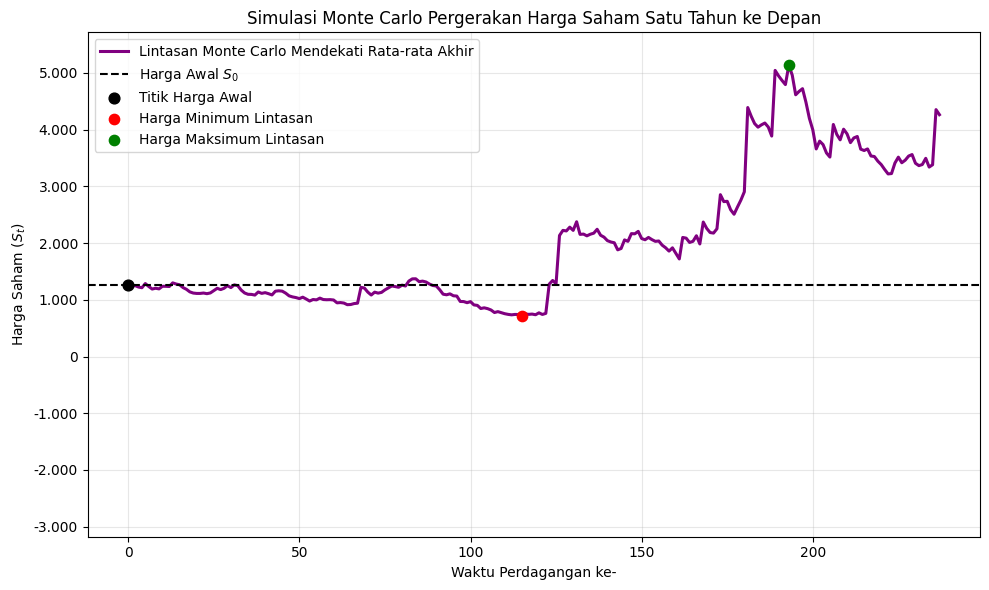

Menampilkan Grafik Volatilitas (Tutup jendela grafik untuk lanjut)...


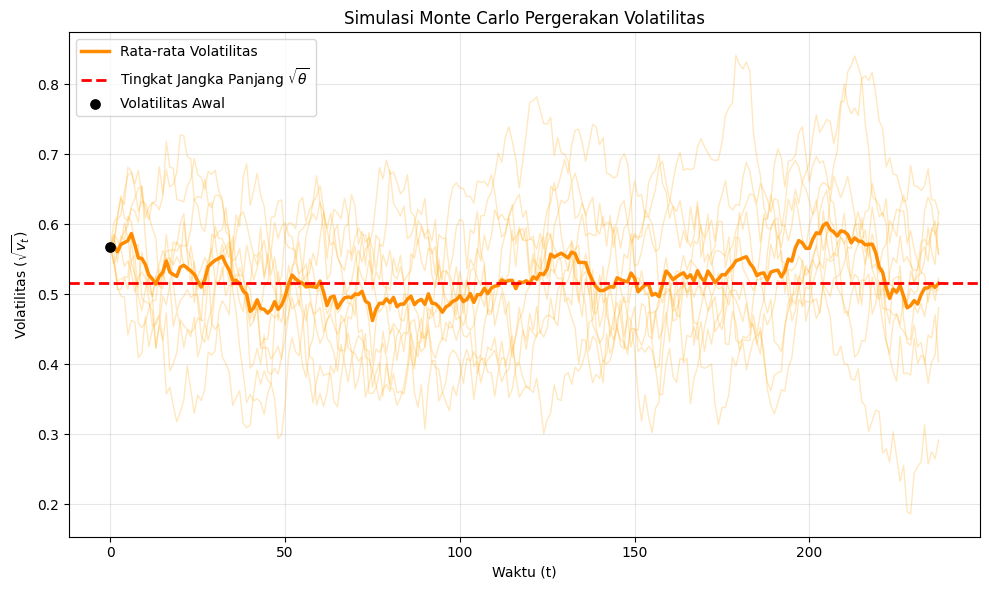

Menampilkan Ilustrasi Sifat Mean Reversion (Tutup jendela grafik untuk lanjut)...


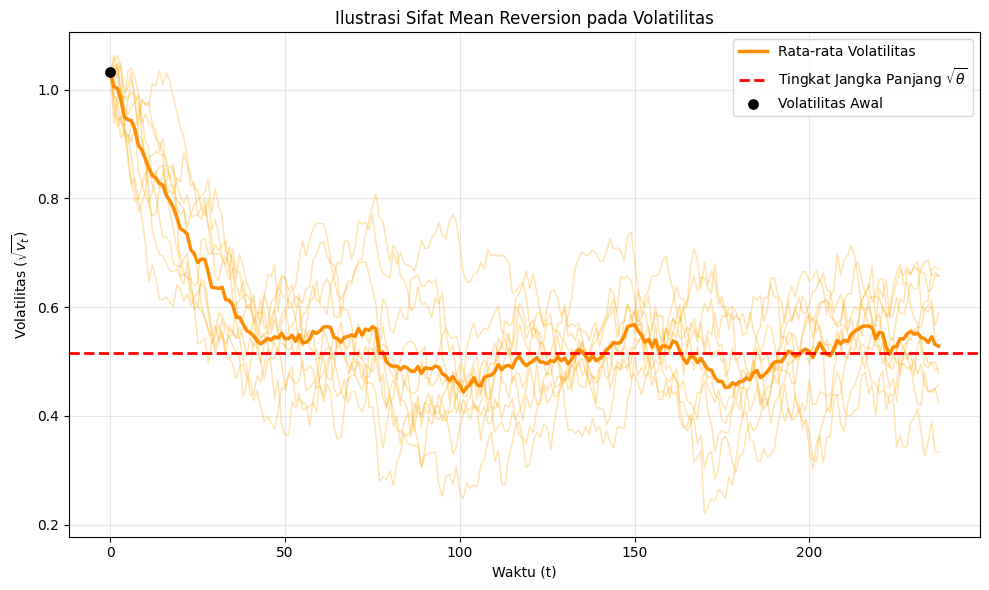


===== STATISTIK PROBABILISTIK HARGA AKHIR =====
Harga awal                    = 1270.0000
Rata-rata harga akhir         = 4466.9692
Median harga akhir            = 2940.3080
Standar deviasi               = 5492.8499
Persentil 5%                  = 765.0538
Persentil 95%                 = 12692.8112
Probabilitas harga naik       = 83.8700%

===== CATATAN SKENARIO EKSTREM, TIDAK UNTUK TABEL UTAMA =====
Harga akhir minimum ekstrem   = 139.2388
Harga akhir maksimum ekstrem  = 121202.7016

File hasil harga akhir Monte Carlo berhasil disimpan: hasil_harga_akhir_monte_carlo_brms.csv
File tabel statistik probabilistik berhasil disimpan: statistik_probabilistik_monte_carlo_brms.csv
Menampilkan Gambar 3.3 (Tutup jendela grafik untuk lanjut)...


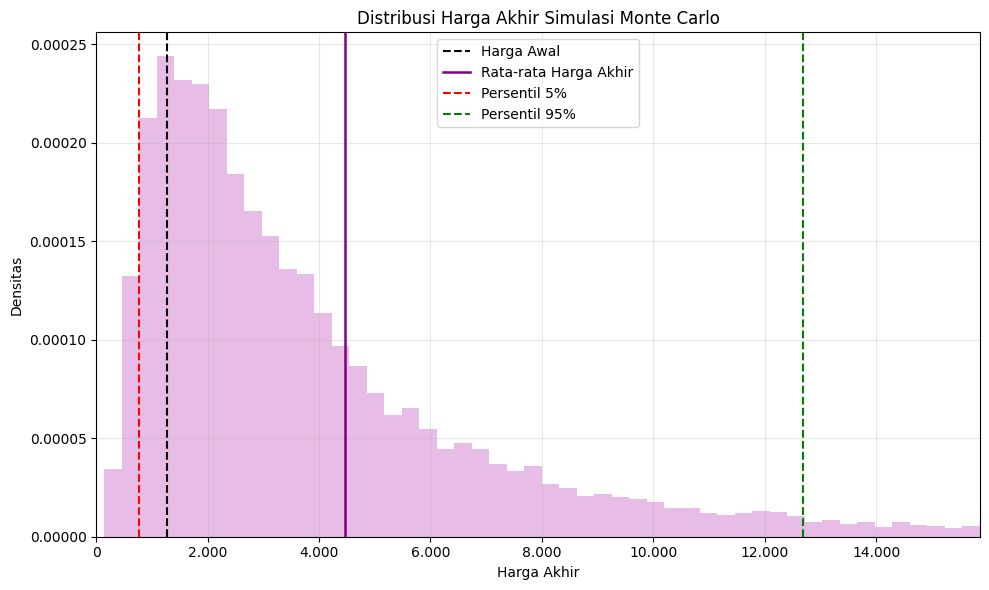


ANALISIS PROBABILITAS DAN VISUALISASI FDT
Harga awal S0            = Rp 1.270
Varians awal v0            = 0.321764
k_J                        = 0.109006
lambda * k_J               = 1.853096

TABEL PERBANDINGAN PROBABILITAS
                  Metode  Probabilitas Kenaikan Harga (%)
             Monte Carlo                        83.870000
Fungsi Densitas Transisi                        83.650445
         Selisih Absolut                         0.219555

TARGET HARGA BERDASARKAN FDT
Target harga FDT           = Rp 1.390
Densitas maksimum FDT      = 0.00023808

File tersimpan:
1. grafik_fungsi_densitas_transisi_brms.png
2. tabel_probabilitas_kenaikan_harga_brms.csv
3. hasil_target_harga_fdt_brms.csv

Menampilkan Grafik Densitas Transisi (Tutup jendela grafik untuk mengakhiri program)...


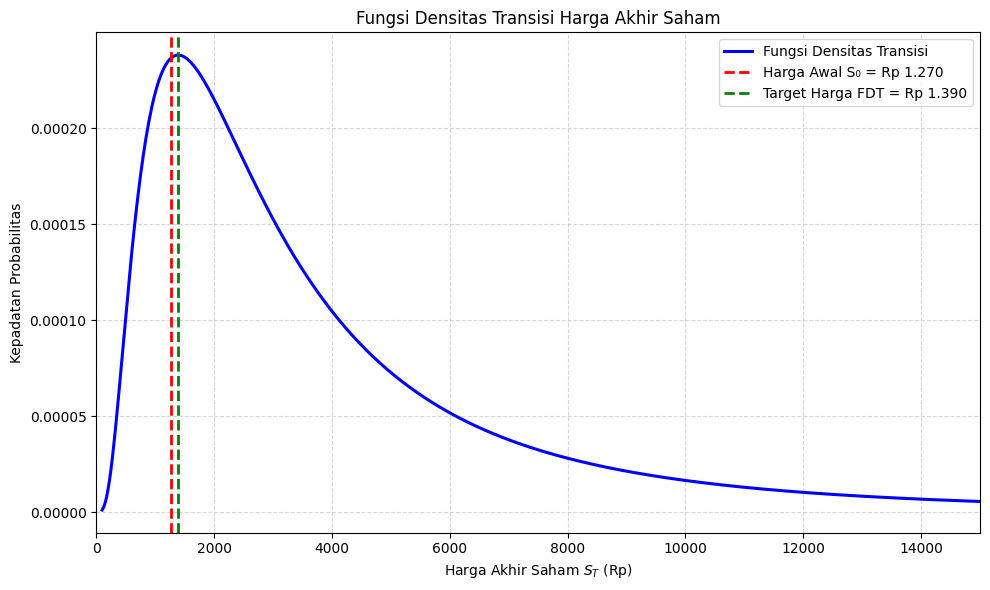

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.integrate import quad
from scipy.optimize import minimize_scalar
import warnings

# Abaikan peringatan divide by zero dari integrasi/regresi
warnings.filterwarnings('ignore')

# =========================================================
# FUNGSI BANTUAN FORMAT GRAFIK
# =========================================================
def rupiah_format(x, pos):
    return f"{int(x):,}".replace(",", ".")

# =========================================================
# 0. INPUT PENGGUNA (TEKS LANGSUNG)
# =========================================================
print("=" * 70)
print("PROGRAM ANALISIS MODEL HESTON-KOU")
print("=" * 70)
input_path = input("Masukkan nama file CSV data saham (contoh: olah_data.csv): ")

if not os.path.exists(input_path):
    print(f"\nError: File '{input_path}' tidak ditemukan.")
    print("Pastikan file berada di folder yang sama dengan script ini.")
    exit()

print(f"\nMemproses file: {input_path}")

# =========================================================
# 1. DISKRETISASI: LOG-PRICE & LOG-RETURN
# =========================================================
df = pd.read_csv(input_path, sep=';')

date_col = "Date"
price_col = "Adj Close"

# Parse tanggal (format Indonesia  dayfirst=True)
df[date_col] = pd.to_datetime(df[date_col], dayfirst=True, errors="coerce")

# Konversi harga ke numerik
df[price_col] = df[price_col].astype(str).str.replace(",", "", regex=False)
df[price_col] = pd.to_numeric(df[price_col], errors="coerce")

# Buang baris invalid & urutkan
df = df.dropna(subset=[date_col, price_col]).copy()
df = df[df[price_col] > 0].copy()
df = df.sort_values(date_col).reset_index(drop=True)

df["X"] = np.log(df[price_col])
df["r"] = df["X"].diff()
df = df.dropna(subset=["r"]).reset_index(drop=True)

dt = 1/237
df["dt"] = dt

# DETEKSI JUMP (MAD)
rvals = df["r"].values
median_r = np.median(rvals)
mad = np.median(np.abs(rvals - median_r))
c = 4.0
threshold = c * mad

df["abs_dev"] = np.abs(df["r"] - median_r)
df["is_jump"] = (df["abs_dev"] > threshold).astype(int)

print("\n--- DETEKSI JUMP ---")
print("MAD:", mad)
print("Threshold:", threshold)
print("Jumlah jump:", df["is_jump"].sum())
print("Proporsi jump (%):", df["is_jump"].mean() * 100)

# RETURN CLEAN (UNTUK TAHAP HESTON)
df["r_clean"] = df["r"].where(df["is_jump"] == 0, np.nan)

# PROXY VARIANS
df["v_proxy"] = (df["r_clean"] ** 2) / dt
df["v_proxy_ma10"] = df["v_proxy"].rolling(10, min_periods=1).mean()
df["v_proxy_ma20"] = df["v_proxy"].rolling(20, min_periods=1).mean()

# SIMPAN OUTPUT
output_cols = [
    date_col, price_col, "X", "r",
    "abs_dev", "is_jump", "r_clean",
    "v_proxy", "v_proxy_ma10", "v_proxy_ma20", "dt"
]

out = df[output_cols].copy()
out_path = "BRMS_discretized.csv"
out.to_csv(out_path, index=False)

print("\nSelesai. Output disimpan ke:", out_path)
print(out.head(5))

# Print Keseluruhan DF (seperti kode asli)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

# =========================================================
# 2. STATISTIK LOMPATAN (TABEL SKRIPSI)
# =========================================================
df_jump = out[out['is_jump'] == 1].copy()
df_jump['Date'] = pd.to_datetime(df_jump['Date'])

tabel = pd.DataFrame()
tabel['Jenis Lompatan'] = df_jump['r'].apply(lambda x: 'Naik (Positif)' if x > 0 else 'Turun (Negatif)')
tabel['Tanggal'] = df_jump['Date'].dt.strftime('%d-%m-%Y')
tabel['Return (Magnitude)'] = df_jump['r'].round(4)

lompatan_naik = tabel[tabel['Jenis Lompatan'] == 'Naik (Positif)']
lompatan_turun = tabel[tabel['Jenis Lompatan'] == 'Turun (Negatif)']

print(f"\n=== STATISTIK LOMPATAN ===")
print(f"Total Jumlah Lompatan : {len(tabel)}")
print(f"Lompatan Naik (Positif): {len(lompatan_naik)}")
print(f"Lompatan Turun (Negatif): {len(lompatan_turun)}")

print(f"\n=== DAFTAR LOMPATAN NAIK (POSITIF) ===")
if not lompatan_naik.empty:
    print(lompatan_naik[['Tanggal', 'Return (Magnitude)']].to_string(index=False))
else:
    print("Tidak ada lompatan naik.")

print(f"\n=== DAFTAR LOMPATAN TURUN (NEGATIF) ===")
if not lompatan_turun.empty:
    print(lompatan_turun[['Tanggal', 'Return (Magnitude)']].to_string(index=False))
else:
    print("Tidak ada lompatan turun.")

# =========================================================
# 3. ESTIMASI PARAMETER HESTON-KOU
# =========================================================
total_years = len(out) * dt

print("\n--- Estimasi Parameter Jump (Kou) ---")
num_jumps = len(df_jump)
lambda_jump = num_jumps / total_years

print(f"Jumlah Jump: {num_jumps}")
print(f"Total Durasi (Tahun): {total_years:.4f}")
print(f"Lambda (Intensitas): {lambda_jump:.4f}")

jump_sizes = df_jump['r'].values
pos_jumps = jump_sizes[jump_sizes > 0]
neg_jumps = jump_sizes[jump_sizes < 0]

if num_jumps > 0:
    p_prob = len(pos_jumps) / num_jumps
    q_prob = 1.0 - p_prob
else:
    p_prob = 0.5
    q_prob = 0.5

eta1 = 1.0 / np.mean(pos_jumps) if len(pos_jumps) > 0 else 0.0
eta2 = 1.0 / np.mean(np.abs(neg_jumps)) if len(neg_jumps) > 0 else 0.0

kou_params = {
    'Parameter': ['Lambda', 'p', 'q', 'Eta1', 'Eta2'],
    'Value': [lambda_jump, p_prob, q_prob, eta1, eta2],
    'Description': [
        'Intensitas Jump per tahun',
        'Probabilitas Jump Naik',
        'Probabilitas Jump Turun',
        'Rate Eksponensial Positif',
        'Rate Eksponensial Negatif'
    ]
}
kou_df = pd.DataFrame(kou_params)
print(kou_df.to_string(index=True))

print("\n--- Estimasi Parameter Heston (Difusi) ---")
v = out['v_proxy_ma20'].values
valid_idx = np.isfinite(v)
v = v[valid_idx]

if len(v) > 10:
    v_curr = v[:-1]
    v_next = v[1:]
    Y = (v_next - v_curr) / dt
    X = v_curr
    slope, intercept = np.polyfit(X, Y, 1)
    kappa = -slope
    theta = intercept / kappa

    residuals = Y - (intercept + slope * X)
    sigma_v = np.std(residuals) / np.sqrt(np.mean(X) * dt)

    df_reg = out.dropna(subset=['v_proxy_ma20', 'r_clean']).copy()
    if len(df_reg) > 10:
        v_reg = df_reg['v_proxy_ma20'].values
        r_reg = df_reg['r_clean'].values
        v_c = v_reg[:-1]
        v_n = v_reg[1:]
        dV_dt = (v_n - v_c) / dt
        resid_reg = dV_dt - (intercept + slope * v_c)
        r_next_reg = r_reg[1:]
        rho = np.corrcoef(r_next_reg, resid_reg)[0, 1]
    else:
        rho = 0
else:
    kappa, theta, sigma_v, rho = 0, 0, 0, 0

mean_total_return = out['r'].mean()
mu_est = (mean_total_return / dt) + (0.5 * theta)

heston_params = {
    'Parameter': ['Kappa', 'Theta', 'Sigma_v', 'Rho', 'Mu'],
    'Value': [kappa, theta, sigma_v, rho, mu_est],
    'Description': [
        'Kecepatan Mean Reversion Varians',
        'Varians Jangka Panjang',
        'Volatilitas dari Varians',
        'Korelasi Return-Varians',
        'Drift Return Aset'
    ]
}
heston_df = pd.DataFrame(heston_params)
print(heston_df.to_string(index=True))

combined_df = pd.concat([kou_df, heston_df], ignore_index=True)
output_csv_path = "parameter_heston_kou.csv"
combined_df.to_csv(output_csv_path, index=False)
print(f"\nSemua Parameter (Heston & Kou) tersimpan di satu file: {output_csv_path}")


# =========================================================
# 4. SIMULASI MONTE CARLO
# =========================================================
lam     = lambda_jump
p       = p_prob
S0 = float(out['Adj Close'].iloc[-1])
if 'v_proxy_ma20' in out.columns:
    V0 = float(out['v_proxy_ma20'].dropna().iloc[-1])
else:
    V0 = float(out['v_proxy'].dropna().iloc[-1])
V0 = max(V0, 1e-8)

paths = 10000
Nsteps = 237
T = 1.0
dt_sim = T / Nsteps
np.random.seed(42)

kJ = p * eta1 / (eta1 - 1) + (1 - p) * eta2 / (eta2 + 1) - 1

if sigma_v > 5:
    print("\nPERINGATAN: Sigma_v hasil file terlalu besar, akan diestimasi ulang.")
    v_series = out['v_proxy_ma20'].dropna().values
    v_lag = v_series[:-1]
    dv = np.diff(v_series)
    X_mat = np.column_stack([np.ones(len(v_lag)), v_lag])
    alpha_hat, beta_hat = np.linalg.lstsq(X_mat, dv, rcond=None)[0]
    residual_new = dv - (alpha_hat + beta_hat * v_lag)
    sigma_v_new = np.sqrt(np.mean((residual_new ** 2) / (np.maximum(v_lag, 1e-8) * dt_sim)))
    print(f"Sigma_v lama = {sigma_v:.6f}")
    print(f"Sigma_v baru = {sigma_v_new:.6f}")
    sigma_v = float(sigma_v_new)

print("\n===== PARAMETER SIMULASI =====")
print(f"S0      = {S0:.4f}")
print(f"V0      = {V0:.8f}")
print(f"mu      = {mu_est:.6f}")
print(f"lambda  = {lam:.6f}")
print(f"p       = {p:.6f}")
print(f"eta1    = {eta1:.6f}")
print(f"eta2    = {eta2:.6f}")
print(f"kappa   = {kappa:.6f}")
print(f"theta   = {theta:.8f}")
print(f"sigma_v = {sigma_v:.6f}")
print(f"rho     = {rho:.6f}")
print(f"kJ      = {kJ:.6f}")

prices = np.zeros((paths, Nsteps + 1))
variances = np.zeros((paths, Nsteps + 1))
prices[:, 0] = S0
variances[:, 0] = V0

S_t = np.full(paths, S0, dtype=float)
v_t = np.full(paths, V0, dtype=float)

for t in range(1, Nsteps + 1):
    Z1 = np.random.normal(0, 1, paths)
    Z2 = np.random.normal(0, 1, paths)
    dW1 = np.sqrt(dt_sim) * Z1
    dW2 = np.sqrt(dt_sim) * (rho * Z1 + np.sqrt(max(1 - rho**2, 0)) * Z2)
    v_pos = np.maximum(v_t, 0)

    jump_count = np.random.poisson(lam * dt_sim, paths)
    jumps = np.zeros(paths)
    idx_jump = np.where(jump_count > 0)[0]

    for i in idx_jump:
        total_jump = 0.0
        for _ in range(jump_count[i]):
            u = np.random.uniform()
            if u < p:
                total_jump += np.random.exponential(scale=1 / eta1)
            else:
                total_jump -= np.random.exponential(scale=1 / eta2)
        jumps[i] = total_jump

    S_t = S_t * np.exp((mu_est - lam * kJ - 0.5 * v_pos) * dt_sim + np.sqrt(v_pos) * dW1 + jumps)
    v_new = v_t + kappa * (theta - v_pos) * dt_sim + sigma_v * np.sqrt(v_pos) * dW2
    v_t = np.maximum(v_new, 0)

    prices[:, t] = S_t
    variances[:, t] = v_t

vol_paths = np.sqrt(np.maximum(variances, 0))
time_grid = np.arange(Nsteps + 1)
final_prices = prices[:, -1]
mean_final_temp = np.mean(final_prices)

candidate_n = 500
candidate_idx = np.argsort(np.abs(final_prices - mean_final_temp))[:candidate_n]
down_counts = np.array([np.sum(np.diff(prices[i, :]) < 0) for i in candidate_idx])
rep_path_idx = candidate_idx[np.argmax(down_counts)]

mc_one_line_price = prices[rep_path_idx, :]
min_line_price = np.min(mc_one_line_price)
max_line_price = np.max(mc_one_line_price)
day_min_line = np.argmin(mc_one_line_price)
day_max_line = np.argmax(mc_one_line_price)

sorted_idx = np.argsort(final_prices)
mid = len(sorted_idx) // 2
rep_idx = sorted_idx[mid-5:mid+5]
rep_vols = vol_paths[rep_idx, :]

print("\n===== LINTASAN REPRESENTATIF GAMBAR 3.2 =====")
print(f"Indeks lintasan terpilih               = {rep_path_idx}")
print(f"Harga awal lintasan                    = {mc_one_line_price[0]:.4f}")
print(f"Harga akhir lintasan                   = {mc_one_line_price[-1]:.4f}")
print(f"Rata-rata harga akhir simulasi         = {mean_final_temp:.4f}")
print(f"Selisih dengan rata-rata harga akhir   = {abs(mc_one_line_price[-1] - mean_final_temp):.4f}")
print(f"Jumlah hari penurunan lintasan         = {np.sum(np.diff(mc_one_line_price) < 0)}")

print("\n===== STATISTIK LINTASAN GAMBAR 3.2 =====")
print(f"Harga minimum lintasan Gambar 3.2      = {min_line_price:.4f}")
print(f"Harga maksimum lintasan Gambar 3.2     = {max_line_price:.4f}")
print(f"Harga minimum terjadi pada hari ke     = {day_min_line}")
print(f"Harga maksimum terjadi pada hari ke    = {day_max_line}")

# GRAFIK 3.2: SATU LINE MC
plt.figure(figsize=(10, 6))
plt.plot(time_grid, mc_one_line_price, color='purple', linewidth=2.2, label='Lintasan Monte Carlo Mendekati Rata-rata Akhir')
plt.axhline(S0, color='black', linestyle='--', linewidth=1.5, label='Harga Awal $S_0$')
plt.scatter(0, S0, color='black', s=60, zorder=5, label='Titik Harga Awal')
plt.scatter(day_min_line, min_line_price, color='red', s=55, zorder=5, label='Harga Minimum Lintasan')
plt.scatter(day_max_line, max_line_price, color='green', s=55, zorder=5, label='Harga Maksimum Lintasan')

jarak_atas = abs(max_line_price - S0)
jarak_bawah = abs(S0 - min_line_price)
y_padding = max(jarak_atas, jarak_bawah) * 1.15
if y_padding < 100: y_padding = 100
plt.ylim(S0 - y_padding, S0 + y_padding)
plt.gca().yaxis.set_major_formatter(FuncFormatter(rupiah_format))
plt.xlabel("Waktu Perdagangan ke-")
plt.ylabel("Harga Saham ($S_t$)")
plt.title("Simulasi Monte Carlo Pergerakan Harga Saham Satu Tahun ke Depan")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Gambar_3_2_Simulasi_Monte_Carlo_Satu_Line.png", dpi=300, bbox_inches='tight')
print("\nMenampilkan Gambar 3.2 (Tutup jendela grafik untuk lanjut)...")
plt.show()

# GRAFIK VOLATILITAS
vol_mean = np.mean(rep_vols, axis=0)
theta_vol = np.sqrt(theta)
plt.figure(figsize=(10, 6))
for i in range(rep_vols.shape[0]):
    plt.plot(time_grid, rep_vols[i, :], color='orange', alpha=0.25, linewidth=1.0)
plt.plot(time_grid, vol_mean, color='darkorange', linewidth=2.5, label='Rata-rata Volatilitas')
plt.axhline(theta_vol, color='red', linestyle='--', linewidth=2.0, label=r'Tingkat Jangka Panjang $\sqrt{\theta}$')
plt.scatter(0, np.sqrt(V0), color='black', s=45, zorder=5, label='Volatilitas Awal')
plt.xlabel("Waktu (t)")
plt.ylabel("Volatilitas ($\sqrt{v_t}$)")
plt.title("Simulasi Monte Carlo Pergerakan Volatilitas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
print("Menampilkan Grafik Volatilitas (Tutup jendela grafik untuk lanjut)...")
plt.show()

# GRAFIK MEAN REVERSION
demo_paths = 10
V0_demo = max(4 * theta, V0)
v_demo = np.full(demo_paths, V0_demo)
demo_variances = np.zeros((demo_paths, Nsteps + 1))
demo_variances[:, 0] = V0_demo
np.random.seed(123)

for t in range(1, Nsteps + 1):
    Z = np.random.normal(0, 1, demo_paths)
    dW = np.sqrt(dt_sim) * Z
    v_demo_pos = np.maximum(v_demo, 0)
    v_demo_new = v_demo + kappa * (theta - v_demo_pos) * dt_sim + sigma_v * np.sqrt(v_demo_pos) * dW
    v_demo = np.maximum(v_demo_new, 0)
    demo_variances[:, t] = v_demo

demo_vols = np.sqrt(np.maximum(demo_variances, 0))
demo_vol_mean = np.mean(demo_vols, axis=0)

plt.figure(figsize=(10, 6))
for i in range(demo_paths):
    plt.plot(time_grid, demo_vols[i, :], color='orange', alpha=0.30, linewidth=1.1)
plt.plot(time_grid, demo_vol_mean, color='darkorange', linewidth=2.5, label='Rata-rata Volatilitas')
plt.axhline(theta_vol, color='red', linestyle='--', linewidth=2.0, label=r'Tingkat Jangka Panjang $\sqrt{\theta}$')
plt.scatter(0, np.sqrt(V0_demo), color='black', s=45, zorder=5, label='Volatilitas Awal')
plt.xlabel("Waktu (t)")
plt.ylabel("Volatilitas ($\sqrt{v_t}$)")
plt.title("Ilustrasi Sifat Mean Reversion pada Volatilitas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
print("Menampilkan Ilustrasi Sifat Mean Reversion (Tutup jendela grafik untuk lanjut)...")
plt.show()

# STATISTIK PROBABILISTIK
mean_final = np.mean(final_prices)
median_final = np.median(final_prices)
std_final = np.std(final_prices)
p05_final = np.percentile(final_prices, 5)
p95_final = np.percentile(final_prices, 95)
min_final = np.min(final_prices)
max_final = np.max(final_prices)
prob_up = np.mean(final_prices > S0)

print("\n===== STATISTIK PROBABILISTIK HARGA AKHIR =====")
print(f"Harga awal                    = {S0:.4f}")
print(f"Rata-rata harga akhir         = {mean_final:.4f}")
print(f"Median harga akhir            = {median_final:.4f}")
print(f"Standar deviasi               = {std_final:.4f}")
print(f"Persentil 5%                  = {p05_final:.4f}")
print(f"Persentil 95%                 = {p95_final:.4f}")
print(f"Probabilitas harga naik       = {prob_up:.4%}")

print("\n===== CATATAN SKENARIO EKSTREM, TIDAK UNTUK TABEL UTAMA =====")
print(f"Harga akhir minimum ekstrem   = {min_final:.4f}")
print(f"Harga akhir maksimum ekstrem  = {max_final:.4f}")

df_hasil_mc = pd.DataFrame({
    "Simulasi_ke": np.arange(1, paths + 1),
    "Harga_Awal": S0,
    "Harga_Akhir": final_prices,
    "Status": np.where(final_prices > S0, "Naik", "Turun")
})
df_hasil_mc.to_csv("hasil_harga_akhir_monte_carlo_brms.csv", index=False)
print("\nFile hasil harga akhir Monte Carlo berhasil disimpan: hasil_harga_akhir_monte_carlo_brms.csv")

df_statistik_probabilistik = pd.DataFrame({
    "Statistik": ["Harga Awal", "Rata-rata Harga Akhir", "Median Harga Akhir", "Standar Deviasi", "Persentil 5%", "Persentil 95%", "Probabilitas Harga Naik"],
    "Nilai": [S0, mean_final, median_final, std_final, p05_final, p95_final, prob_up]
})
df_statistik_probabilistik.to_csv("statistik_probabilistik_monte_carlo_brms.csv", index=False)
print("File tabel statistik probabilistik berhasil disimpan: statistik_probabilistik_monte_carlo_brms.csv")

# HISTOGRAM
x_max = p95_final * 1.25
final_prices_plot = final_prices[final_prices <= x_max]

plt.figure(figsize=(10, 6))
plt.hist(final_prices_plot, bins=50, density=True, alpha=0.7, color='plum')
plt.axvline(S0, color='black', linestyle='--', linewidth=1.5, label='Harga Awal')
plt.axvline(mean_final, color='purple', linestyle='-', linewidth=1.8, label='Rata-rata Harga Akhir')
plt.axvline(p05_final, color='red', linestyle='--', linewidth=1.5, label='Persentil 5%')
plt.axvline(p95_final, color='green', linestyle='--', linewidth=1.5, label='Persentil 95%')
plt.xlim(0, x_max)
plt.gca().xaxis.set_major_formatter(FuncFormatter(rupiah_format))
plt.xlabel("Harga Akhir")
plt.ylabel("Densitas")
plt.title("Distribusi Harga Akhir Simulasi Monte Carlo")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Gambar_3_3_Distribusi_Harga_Akhir_Monte_Carlo.png", dpi=300, bbox_inches='tight')
print("Menampilkan Gambar 3.3 (Tutup jendela grafik untuk lanjut)...")
plt.show()

# =========================================================
# 5. ANALISIS PROBABILITAS DAN VISUALISASI FDT
# =========================================================
print("\n" + "=" * 70)
print("ANALISIS PROBABILITAS DAN VISUALISASI FDT")
print("=" * 70)

k_J_fdt = (p * eta1) / (eta1 - 1) + ((1 - p) * eta2) / (eta2 + 1) - 1

def phi_heston_kou(u):
    i = 1j
    b = kappa - rho * sigma_v * i * u
    d = np.sqrt(b**2 + sigma_v**2 * (u**2 + i * u))
    g = (b - d) / (b + d)

    C = (i * u * (mu_est - lam * k_J_fdt) * T +
         (kappa * theta / sigma_v**2) * ((b - d) * T - 2 * np.log((1 - g * np.exp(-d * T)) / (1 - g))))
    D = ((b - d) / sigma_v**2 * ((1 - np.exp(-d * T)) / (1 - g * np.exp(-d * T))))

    phi_Y = (p * eta1) / (eta1 - i * u) + ((1 - p) * eta2) / (eta2 + i * u)
    jump_term = lam * T * (phi_Y - 1)

    return np.exp(i * u * np.log(S0) + C + D * V0 + jump_term)

def integrand_prob(u):
    K = S0
    value = np.exp(-1j * u * np.log(K)) * phi_heston_kou(u) / (1j * u)
    return value.real

integral_value, error_prob = quad(integrand_prob, 1e-8, 500, limit=300)
prob_fdt = 0.5 + (1 / np.pi) * integral_value
prob_mc = prob_up

def density_fdt(S_val):
    if S_val <= 0: return 0
    x = np.log(S_val)
    def integrand_pdf(u):
        value = np.exp(-1j * u * x) * phi_heston_kou(u)
        return value.real
    integral_pdf, error_pdf = quad(integrand_pdf, 0, 200, limit=200)
    return (1 / np.pi) * integral_pdf / S_val

price_grid_search = np.linspace(100, 8000, 500)
density_grid_search = np.array([density_fdt(S_val) for S_val in price_grid_search])
idx_max = np.argmax(density_grid_search)
lower_bound = price_grid_search[max(idx_max - 3, 0)]
upper_bound = price_grid_search[min(idx_max + 3, len(price_grid_search) - 1)]

result_mode = minimize_scalar(lambda S_val: -density_fdt(S_val), bounds=(lower_bound, upper_bound), method="bounded")
target_fdt = result_mode.x
density_target = -result_mode.fun
selisih = abs(prob_fdt - prob_mc)

tabel_probabilitas = pd.DataFrame({
    "Metode": ["Monte Carlo", "Fungsi Densitas Transisi", "Selisih Absolut"],
    "Probabilitas Kenaikan Harga (%)": [prob_mc * 100, prob_fdt * 100, selisih * 100]
})

print(f"Harga awal S0            = Rp {S0:,.0f}".replace(",", "."))
print(f"Varians awal v0            = {V0:.6f}")
print(f"k_J                        = {k_J_fdt:.6f}")
print(f"lambda * k_J               = {lam * k_J_fdt:.6f}")

print("\nTABEL PERBANDINGAN PROBABILITAS")
print(tabel_probabilitas.to_string(index=False))

print("\nTARGET HARGA BERDASARKAN FDT")
print(f"Target harga FDT           = Rp {target_fdt:,.0f}".replace(",", "."))
print(f"Densitas maksimum FDT      = {density_target:.8f}")

tabel_probabilitas.to_csv("tabel_probabilitas_kenaikan_harga_brms.csv", index=False)
hasil_target_fdt = pd.DataFrame({
    "Keterangan": ["Harga Awal", "Probabilitas Monte Carlo (%)", "Probabilitas FDT (%)", "Selisih Absolut (%)", "Target Harga FDT"],
    "Nilai": [S0, prob_mc * 100, prob_fdt * 100, selisih * 100, target_fdt]
})
hasil_target_fdt.to_csv("hasil_target_harga_fdt_brms.csv", index=False)

print("\nFile tersimpan:")
print("1. grafik_fungsi_densitas_transisi_brms.png")
print("2. tabel_probabilitas_kenaikan_harga_brms.csv")
print("3. hasil_target_harga_fdt_brms.csv")

price_grid_plot = np.linspace(100, 15000, 600)
density_grid_plot = np.array([density_fdt(S_val) for S_val in price_grid_plot])

plt.figure(figsize=(10, 6))
plt.plot(price_grid_plot, density_grid_plot, linewidth=2.2, label="Fungsi Densitas Transisi", color="blue")
plt.axvline(S0, linestyle="--", linewidth=2, label=f"Harga Awal S₀ = Rp {S0:,.0f}".replace(",", "."), color="red")
plt.axvline(target_fdt, linestyle="--", linewidth=2, label=f"Target Harga FDT = Rp {target_fdt:,.0f}".replace(",", "."), color="green")
plt.title("Fungsi Densitas Transisi Harga Akhir Saham")
plt.xlabel("Harga Akhir Saham $S_T$ (Rp)")
plt.ylabel("Kepadatan Probabilitas")
plt.xlim(0, 15000)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("grafik_fungsi_densitas_transisi_brms.png", dpi=300)
print("\nMenampilkan Grafik Densitas Transisi (Tutup jendela grafik untuk mengakhiri program)...")
plt.show()